In [1]:
# Creación aleatoria de datos
import numpy as np
X = np.array([0.5, 23, 0.3, 4.5, 0.3, 0.5,
              -28, -50, 60, -100, -10, -11, 13, 19, 1, 9])

In [2]:
# Medidas de tendencia central
from scipy import stats
media = np.mean(X)
mediana = np.median(X)
moda, _ = stats.mode(X)
print('media: ', media)
print('mediana: ', mediana)
print('moda :', moda)

media:  -4.24375
mediana:  0.5
moda : 0.3


In [3]:
# Medidas de posición
import numpy as np
import matplotlib.pyplot as plt

Q1 = np.percentile(X, 25)
Q3 = np.percentile(X, 75)
RIC = Q3 - Q1
lim_inf = Q1 - 1.5*RIC
lim_sup = Q3 + 1.5*RIC

print('RIC :', RIC)
print('limite inferior :', lim_inf)
print('limite superior :', lim_sup)

RIC : 20.25
limite inferior : -40.625
limite superior : 40.375


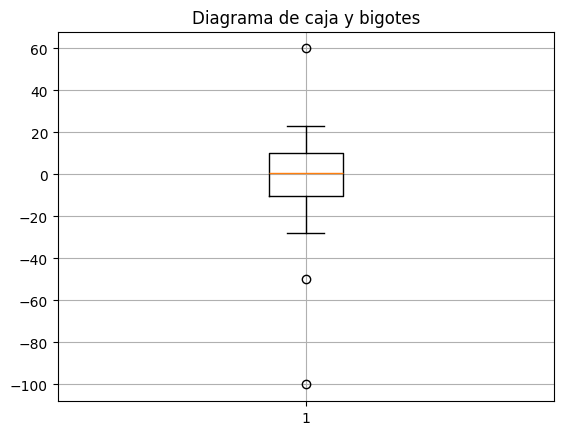

In [4]:
# Dibuja el diagrama de box and whiskers y determina visualmente el número de outliers
plt.boxplot(X)
plt.grid()
plt.title("Diagrama de caja y bigotes")
plt.show()

In [5]:
# Medidas de dispersión
desvest = np.std(X)
print('Desviación típica: ', desvest)
print('Varianza: ', desvest**2)

Desviación típica:  33.521242681880096
Varianza:  1123.6737109375


In [6]:
# Medidas de distribución
asimetria = stats.skew(X)
curtosis = stats.kurtosis(X, fisher=True) # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html
print('Asimetría ', np.round(asimetria, 4))
print('Curtosis ', np.round(curtosis, 4))

if curtosis>0:
    print('Distribución Leptocúrtica')
elif curtosis<0:
    print('Distribución Platicúrtica')
else:
    print('Distribución Mesocúrtica')

Asimetría  -1.1302
Curtosis  2.2858
Distribución Leptocúrtica


In [7]:
# Cargar el set de datos de Iris
from sklearn import datasets
from pprint import pprint
iris = datasets.load_iris()
pprint(iris)
X = iris.data
y = iris.target

# ¿Qué tipo de asimetría se observa en la variable "longitud del pétalo"?
#???

# ¿A qué tipo de distribución se ajusta la variable "ancho del sépalo", según su curtosis?
#???

{'DESCR': '.. _iris_dataset:\n'
          '\n'
          'Iris plants dataset\n'
          '--------------------\n'
          '\n'
          '**Data Set Characteristics:**\n'
          '\n'
          ':Number of Instances: 150 (50 in each of three classes)\n'
          ':Number of Attributes: 4 numeric, predictive attributes and the '
          'class\n'
          ':Attribute Information:\n'
          '    - sepal length in cm\n'
          '    - sepal width in cm\n'
          '    - petal length in cm\n'
          '    - petal width in cm\n'
          '    - class:\n'
          '            - Iris-Setosa\n'
          '            - Iris-Versicolour\n'
          '            - Iris-Virginica\n'
          '\n'
          ':Summary Statistics:\n'
          '\n'
          '============== ==== ==== ======= ===== ====================\n'
          '                Min  Max   Mean    SD   Class Correlation\n'
          '============== ==== ==== ======= ===== ====================\n'
          '

In [8]:
# ¿Qué tipo de asimetría se observa en la variable "longitud del pétalo"?
#???
from scipy import stats

# 1. Seleccionamos la columna de longitud del pétalo (índice 2)
petal_length = X[:, 2]

# 2. Calculamos la asimetría
asimetria_petal = stats.skew(petal_length)

print(f'Asimetría de la longitud del pétalo: {asimetria_petal:.4f}')

# Respuesta a la pregunta:
if asimetria_petal < 0:
    print("Se observa una ASIMETRÍA NEGATIVA (sesgada a la izquierda).")
elif asimetria_petal > 0:
    print("Se observa una ASIMETRÍA POSITIVA (sesgada a la derecha).")
else:
    print("La distribución es simétrica.")

Asimetría de la longitud del pétalo: -0.2721
Se observa una ASIMETRÍA NEGATIVA (sesgada a la izquierda).


In [9]:
# ¿A qué tipo de distribución se ajusta la variable "ancho del sépalo", según su curtosis?
#???
from scipy import stats

# 1. Seleccionamos la columna de ancho del sépalo (índice 1)
sepal_width = X[:, 1]

# 2. Calculamos la curtosis (Fisher por defecto, normal = 0)
curtosis_sepal = stats.kurtosis(sepal_width)

print(f'Curtosis del ancho del sépalo: {curtosis_sepal:.4f}')

# 3. Clasificación
if curtosis_sepal > 0:
    print("La distribución es LEPTOCÚRTICA (más apuntada que la normal).")
elif curtosis_sepal < 0:
    print("La distribución es PLATICÚRTICA (más achatada que la normal).")
else:
    print("La distribución es MESOCÚRTICA (similar a la normal).")

Curtosis del ancho del sépalo: 0.1810
La distribución es LEPTOCÚRTICA (más apuntada que la normal).


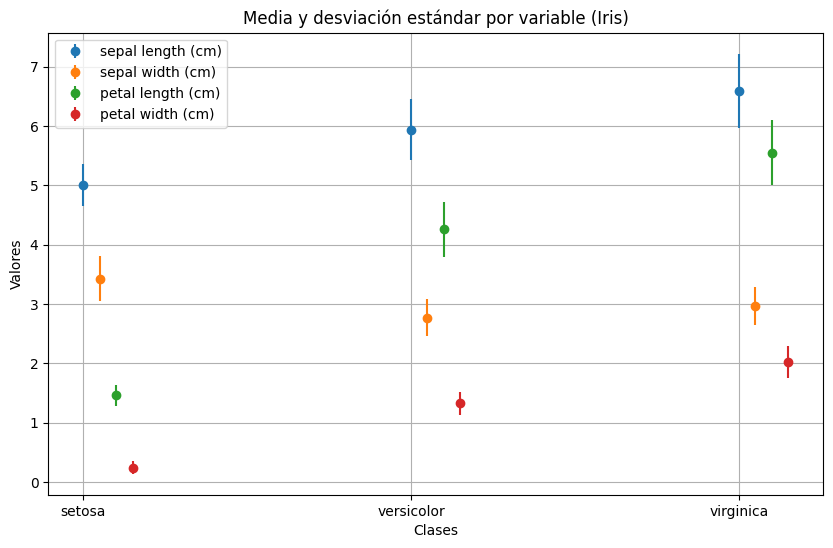

In [11]:
# EJERCICIO EXTRA SOBRE EL DATASET DE IRIS
# Extraer la media y la desviación típica de cada variable en función de la clase y representarlo en un gráfico (plt.errorbar)
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

# Cargar dataset iris
iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
clases = np.unique(y)

# Crear figura
plt.figure(figsize=(10,6))

# Recorrer cada variable (columna)
for i in range(X.shape[1]):
    medias = []
    desv = []

    # Calcular media y desviación por clase
    for c in clases:
        datos_clase = X[y == c, i]
        medias.append(np.mean(datos_clase))
        desv.append(np.std(datos_clase))

    # Graficar con errorbar
    plt.errorbar(clases + i*0.05, medias, yerr=desv, fmt='o', label=feature_names[i])

# Configuración del gráfico
plt.xticks(clases, iris.target_names)
plt.xlabel("Clases")
plt.ylabel("Valores")
plt.title("Media y desviación estándar por variable (Iris)")
plt.legend()
plt.grid()

plt.show()